## DFT vs. MLIP Relaxation Energy Comparison Pipeline

This notebook benchmarks MLIP-relaxed structures against DFT for CO2 reduction
reaction (CO2RR) intermediates adsorbed on a YO4PdCu slab. For each adsorbate
configuration, structures are relaxed by each
MLIP (MACE, MatterSim, UMA), and then compared to the corresponding relaxed DFT (VASP) run via total energy, adsorption energy, and the RMS of the final structures.

Adsorption energy calculated as 
$$E_{ads}^{MLIP} = E_{slab+ads}^{MLIP} - E_{slab}^{DFT} - \sum E_{refs}^{DFT} \\
\text{ and } \\ 
E_{ads}^{DFT} = E_{slab+ads}^{DFT} - E_{slab}^{DFT} - \sum E_{refs}^{DFT} $$
where refs are DFT potential energies of gas-phase reference molecules.

**Directory Setup** \
To run this notebook, make sure your directory structure mimics this:

Note that the data in dft-data/ can be switched out with other DFT run data if you 
1. follow the existing directory structure
2. update the path format template in the user input cell below

#### 0. Configuration

In [61]:
from pathlib import Path
from ase.io import iread, read, write

In [62]:
# builds a dict describing 1 DFT adsorbate run
# ads: single adsorbate string or two joined like ads1_ads2
# template: path template string with {ads}, {slab}, {config_id} placeholders;
#           define at call site (TEMPLATE in next cell) to handle
#           directory structure variants.

def make_run(ads, slab, config_id, template):
    run_id = f"{ads}_{slab}_{config_id}"
    return {
        "ads":       ads,
        "slab":      slab,
        "config_id": config_id,  # use arbitrary directory numbering to label ads config for now
        "run_id":    run_id,
        "path":      template.format(ads=ads, slab=slab, config_id=config_id),
    }

def make_model(name, python_bin, script_path):
    return {
        "name":       name,
        "python_bin": python_bin,
        "script":     script_path
    }

In [63]:
# =====USER INPUT HERE=====

# do you want to re-run model relaxations? (note: takes time!)
RUN_RELAXATIONS = False  # set to True when ready to run models
# if RUN_RELAXATIONS = True, do you want to avoid overwriting files
# of model output already written?
OVERWRITE_RELAXATIONS = True  # set to False if you want to continue an interrupted run

# directory path template for adsorbate systems on YPdCu slab
YPDCU_TEMPLATE = "dft-data/YPdCu/{ads}_on_{slab}/{ads}_{slab}_{config_id}/vasprun.xml"

# enter slab folder name here (fix later):
slab_folder = "YPdCu_slab"

RUNS = (
    [make_run("CH3CHO",       "YO4PdCu", 3, YPDCU_TEMPLATE)] +
    [make_run("CO_CHO",       "YO4PdCu", i, YPDCU_TEMPLATE) for i in range(1, 15)] +
    [make_run("COCHO",        "YO4PdCu", i, YPDCU_TEMPLATE) for i in range(1, 19)] +
    [make_run("COOH",         "YO4PdCu", i, YPDCU_TEMPLATE) for i in range(1, 16)]
)

MODELS = [
    make_model("MACE",       "/Users/zschwab/miniconda3/envs/mlip-mace/bin/python",       "model-scripts/run_mace.py"     ),
    make_model("MatterSim",  "/Users/zschwab/miniconda3/envs/mlip-mattersim/bin/python",  "model-scripts/run_mattersim.py"),
    make_model("UMA",        "/Users/zschwab/miniconda3/envs/mlip-uma/bin/python",        "model-scripts/run_uma.py"      ),
]

#### 1. DFT data ingestion 
(extract all frames from DFT runs)

In [64]:
# load vasp trajectories into ASE Atoms obj.

# for trajectory files with multiple steps
def load_frames(path):
    frames = []
    for f in iread(path):
        frames.append(f)
    return frames

# for single-structure files (references, loads last by default)
def load_frame(path, index=-1):
    frame = read(path, index=index)
    return frame

In [65]:
# converts DFT trajectories -> .xyz files for MLIP runner scripts to read
# writes .xyz output files to hold model results later

if RUN_RELAXATIONS:
    for run in RUNS:
        outfile = Path(f"dft-trajectories/{run['run_id']}_dft.xyz")
        
        if not outfile.exists():
            write(outfile, load_frames(run['path']))
else:
    print("Cell skipped!")

Cell skipped!


#### 2. run MLIPs (MACE, MatterSim, UMA)

In [66]:
if RUN_RELAXATIONS:
    # find device to run model on
    import torch

    if torch.backends.mps.is_built() and torch.backends.mps.is_available():
        device = "mps"   # for apple silicon gpus (M-series chips)
    elif torch.cuda.is_available():
        device = "cuda"  # for gpus w/ nvidia cuda backend
    else:
        device = "cpu"   # default 
    
    print(f"{device} found!")

In [67]:
# runs each MLIP runner script as a subprocess using that model's own conda env
# each script reads the .xyz inputs and writes a .npz file (numpy filetype) 
# with predicted E, F(r)

import subprocess
import os

if RUN_RELAXATIONS:
    # new env inherits current environment as a starting point
    env = os.environ.copy()

    # disable GUI dependencies vscode auto-imports when launching a subprocess from
    # a python notebook b/c they conflict with model dependencies and are unneeded
    env["MPLBACKEND"] = "Agg"

    for model in MODELS:
        for run in RUNS:
            # in: path to POSCAR files of dft runs
            in_path = f"dft-data/YPdCu/{run['ads']}_on_{run['slab']}/{run['run_id']}/POSCAR"
            out_path = f"mlip-trajectories/{model['name']}/{run['run_id']}_{model['name'].lower()}.traj"

            if not OVERWRITE_RELAXATIONS:
                if os.path.exists(out_path):
                    continue

            r = subprocess.run(
                [model['python_bin'], model['script'], in_path, out_path, device],
                capture_output=True, text=True, env=env
            )
            if r.returncode != 0:
                print(f"-- [{run['run_id']}] ({model['name']}): failed")
                if r.stdout: print(r.stdout)
                if r.stderr: print(r.stderr)
                print("Return code:", r.returncode)
            else:
                print(f"-- [{run['run_id']}] ({model['name']}): success")
else:
    print("Cell skipped!")

Cell skipped!


In [68]:
# runs each MLIP runner script as a subprocess using that model's own conda env
# each script reads the .xyz inputs and writes a .npz file (numpy filetype) 
# with predicted E, F(r)

import subprocess
import os

if RUN_RELAXATIONS:
    # new env inherits current environment as a starting point
    env = os.environ.copy()

    # disable GUI dependencies vscode auto-imports when launching a subprocess from
    # a python notebook b/c they conflict with model dependencies and are unneeded
    env["MPLBACKEND"] = "Agg"

    for model in MODELS:
        for run in RUNS:
            # in: path to POSCAR files of dft runs
            in_path = f"dft-data/YPdCu/{run['ads']}_on_{run['slab']}/{run['run_id']}/POSCAR"
            out_path = f"mlip-trajectories/{model['name']}/{run['run_id']}_{model['name'].lower()}.traj"
            r = subprocess.run(
                [model['python_bin'], model['script'], in_path, out_path, device],
                capture_output=True, text=True, env=env
            )
            if r.returncode != 0:
                print(f"-- [{run['run_id']}] ({model['name']}): failed")
                if r.stdout: print(r.stdout)
                if r.stderr: print(r.stderr)
                print("Return code:", r.returncode)
            else:
                print(f"-- [{run['run_id']}] ({model['name']}): success")
else:
    print("Cell skipped!")

Cell skipped!


#### 3. Calculate adsorbate energies

In [69]:
# get bare slab & reference energies

REFS= {  # reference adsorbate energies
    "CO" :  None,
    "CO2":  None,
    "H2" :  None,
    "H2O":  None,
}

for mol in REFS:
    REFS[mol] = load_frame(f"../../dft-ref-energy-data/adsorbates/{mol}_gas/vasprun.xml").get_potential_energy()

slab = load_frame("../../dft-ref-energy-data/slabs/YO4PdCu/vasprun.xml")
slab_energy = slab.get_potential_energy()

In [70]:
# define formulas for E_adsorbed = E_total - E_slab - E_adsorbates

def calc_CH3CHO(total_energy):
    return total_energy - slab_energy + REFS["H2O"] - 2*REFS["CO"] - 3*REFS["H2"]

def calc_COCHO(total_energy):
    return total_energy - slab_energy - 2*REFS["CO"] - (1/2)*REFS["H2"]

def calc_COOH(total_energy):
    return total_energy - slab_energy - REFS["CO2"] - (1/2)*REFS["H2"]

#### 4. Plot results

##### 4a. Load data, filter outliers

In [89]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.ticker import FormatStrFormatter


ADSORBATE_CALCS = {
    "CH3CHO": calc_CH3CHO,   # don't bother plotting single point
    "CO_CHO": calc_COCHO,
    "COCHO" : calc_COCHO,
    "COOH"  : calc_COOH,
}

atoms_dict = {"DFT": {}}
records = []

for run in RUNS:
    atoms = read(f"dft-trajectories/{run['run_id']}_dft.xyz", index=-1)
    total = atoms.get_potential_energy()
    atoms_dict["DFT"][run['run_id']] = atoms
    records.append({
        "model": "DFT", "ads": run['ads'], "run_id": run['run_id'],
        "total": total, "adsorbed": ADSORBATE_CALCS[run['ads']](total),
    })

for model in MODELS:
    atoms_dict[model['name']] = {}
    for run in RUNS:
        path = f"mlip-trajectories/{model['name']}/{run['run_id']}_{model['name'].lower()}.traj"
        atoms = read(path, index=-1)
        total = atoms.get_potential_energy()
        atoms_dict[model['name']][run['run_id']] = atoms
        records.append({
            "model": model['name'], "ads": run['ads'], "run_id": run['run_id'],
            "total": total, "adsorbed": ADSORBATE_CALCS[run['ads']](total),
        })

df = pd.DataFrame(records)

# merge DFT reference values onto each MLIP row
dft = df[df['model'] == 'DFT'][['ads', 'run_id', 'total', 'adsorbed']]
dft = dft.rename(columns={'total': 'dft_total', 'adsorbed': 'dft_adsorbed'})
df = df.merge(dft, on=['ads', 'run_id'], how='left')

In [91]:
def filter_outliers(x, y, keys, thresh=3.5):
    x, y = np.array(x), np.array(y)
    resid = y - x
    med = np.median(resid)
    mad = np.median(np.abs(resid - med))
    if mad == 0:
        mask = np.ones_like(resid, dtype=bool)
    else:
        mod_z = 0.6745 * (resid - med) / mad
        mask = np.abs(mod_z) < thresh
    dropped = [(k, xi, yi) for k, xi, yi, m in zip(keys, x, y, mask) if not m]
    return mask, dropped

##### 4b. Plots

In [92]:
# reusable parity plot grid
COLORS = plt.cm.tab10.colors
def parity_plot(df, energy_col, title, drop_outliers=False, show_outlier_table=False):
    fig, axes = plt.subplots(nrows=len(ADSORBATE_CALCS), ncols=len(MODELS),
                            figsize=(5*len(MODELS), 4*len(ADSORBATE_CALCS)))
    outlier_rows = []
    dft_col = f"dft_{energy_col}"
    for row, ads in enumerate(ADSORBATE_CALCS):
        for col, (model, color) in enumerate(zip(MODELS, COLORS)):
            ax = axes[row][col]
            subset = df[(df['model'] == model['name']) & (df['ads'] == ads)]
            x = subset[dft_col].to_numpy()
            y = subset[energy_col].to_numpy()
            keys = subset['run_id'].tolist()
            n_dropped = 0
            if drop_outliers:
                mask, dropped = filter_outliers(x, y, keys)
                if show_outlier_table:
                    for k, xi, yi in dropped:
                        outlier_rows.append({
                            "model": model['name'], "ads": ads, "run_id": k,
                            "dft_energy": xi, "mlip_energy": yi, "difference": yi - xi
                        })
                x, y = x[mask], y[mask]
                n_dropped = len(dropped)
            if len(x) >= 2:
                r2 = pearsonr(x, y).statistic ** 2
                label = f"$r^2$={r2:.3f}" + (f", {n_dropped} excl." if n_dropped else "")
            else:
                label = "n=1"
            ax.scatter(x, y, marker='+', s=80, label=label, color=color)
            ax.legend(loc='lower center')
            padding = 0.05 * (max(x.max(), y.max()) - min(x.min(), y.min()))
            lim = [min(x.min(), y.min()) - padding, max(x.max(), y.max()) + padding]
            ax.set_xlim(lim)
            ax.set_ylim(lim)
            ax.set_xticks(np.linspace(lim[0], lim[1], 6))
            ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
            ax.plot(lim, lim, color='gray', linestyle='--', linewidth=1)
            ax.grid(color='lightgrey', linewidth=0.5)
            ax.set_xlabel("DFT energy (eV)")
            if col == 0:
                ax.set_ylabel("MLIP energy (eV)")
            else:
                ax.tick_params(labelleft=False)
            if row == 0:
                ax.set_title(model['name'], fontsize=12)
            if col == 0:
                ax.set_ylabel(ads, fontsize=12, labelpad=8)
    plt.suptitle(title, y=0.99, fontsize=14)
    plt.tight_layout()
    plt.show()
    if drop_outliers and outlier_rows:
        out_df = pd.DataFrame(outlier_rows)
        print("\nOutlier summary table:")
        print(out_df)

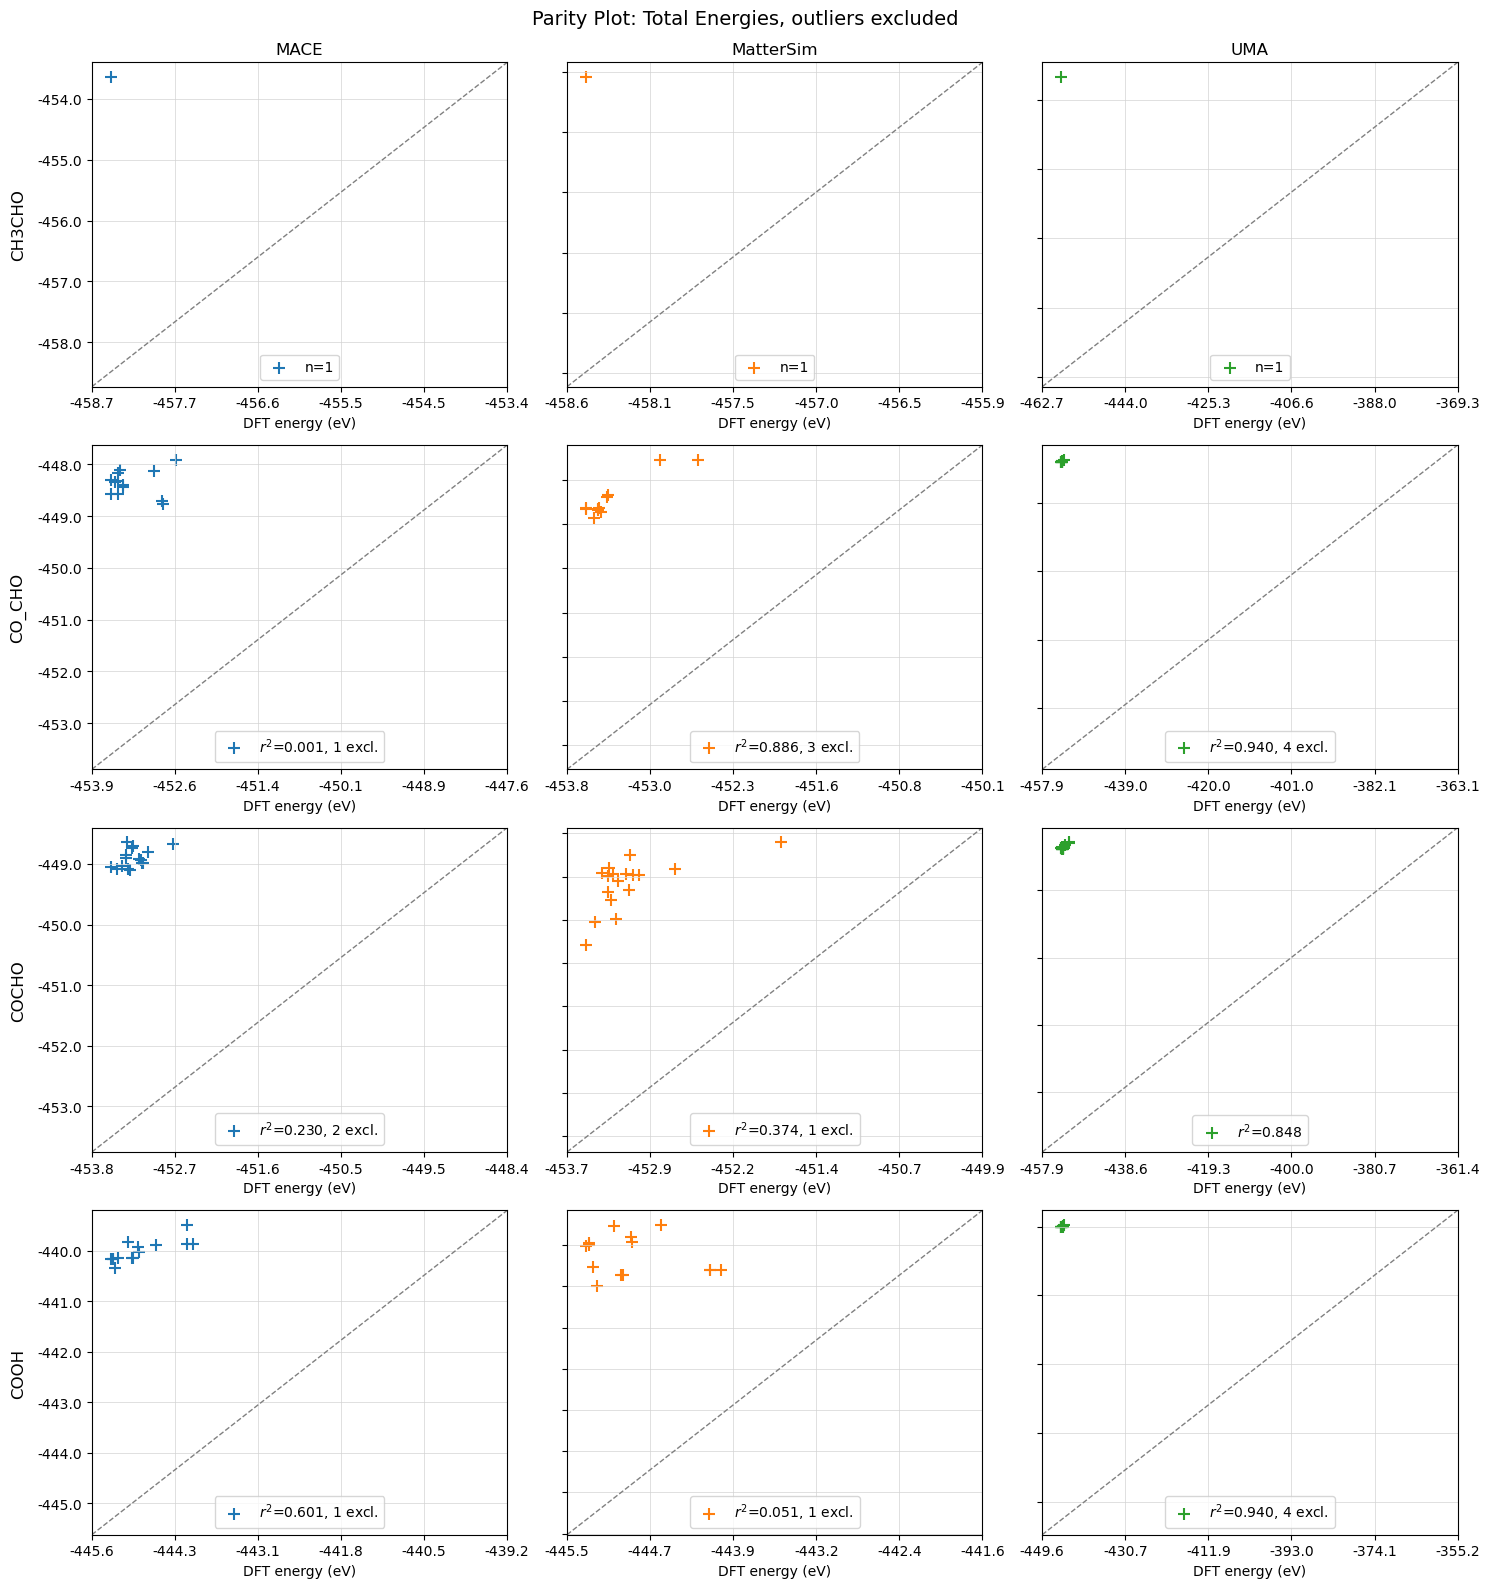


Outlier summary table:
        model     ads             run_id  dft_energy  mlip_energy  difference
0        MACE  CO_CHO   CO_CHO_YO4PdCu_4 -428.745060  -447.279419  -18.534358
1   MatterSim  CO_CHO   CO_CHO_YO4PdCu_4 -428.745060  -450.533966  -21.788906
2   MatterSim  CO_CHO   CO_CHO_YO4PdCu_8 -452.825718  -450.801910    2.023808
3   MatterSim  CO_CHO  CO_CHO_YO4PdCu_12 -452.811206  -451.023834    1.787372
4         UMA  CO_CHO   CO_CHO_YO4PdCu_4 -428.745060  -367.735638   61.009423
5         UMA  CO_CHO   CO_CHO_YO4PdCu_8 -452.825718  -367.881391   84.944327
6         UMA  CO_CHO  CO_CHO_YO4PdCu_11 -452.619984  -367.568721   85.051263
7         UMA  CO_CHO  CO_CHO_YO4PdCu_12 -452.811206  -367.677309   85.133897
8        MACE   COCHO    COCHO_YO4PdCu_2 -451.753580  -448.509094    3.244485
9        MACE   COCHO    COCHO_YO4PdCu_3 -451.717484  -448.546783    3.170701
10  MatterSim   COCHO    COCHO_YO4PdCu_3 -451.717484  -451.029816    0.687669
11       MACE    COOH     COOH_YO4PdCu_2

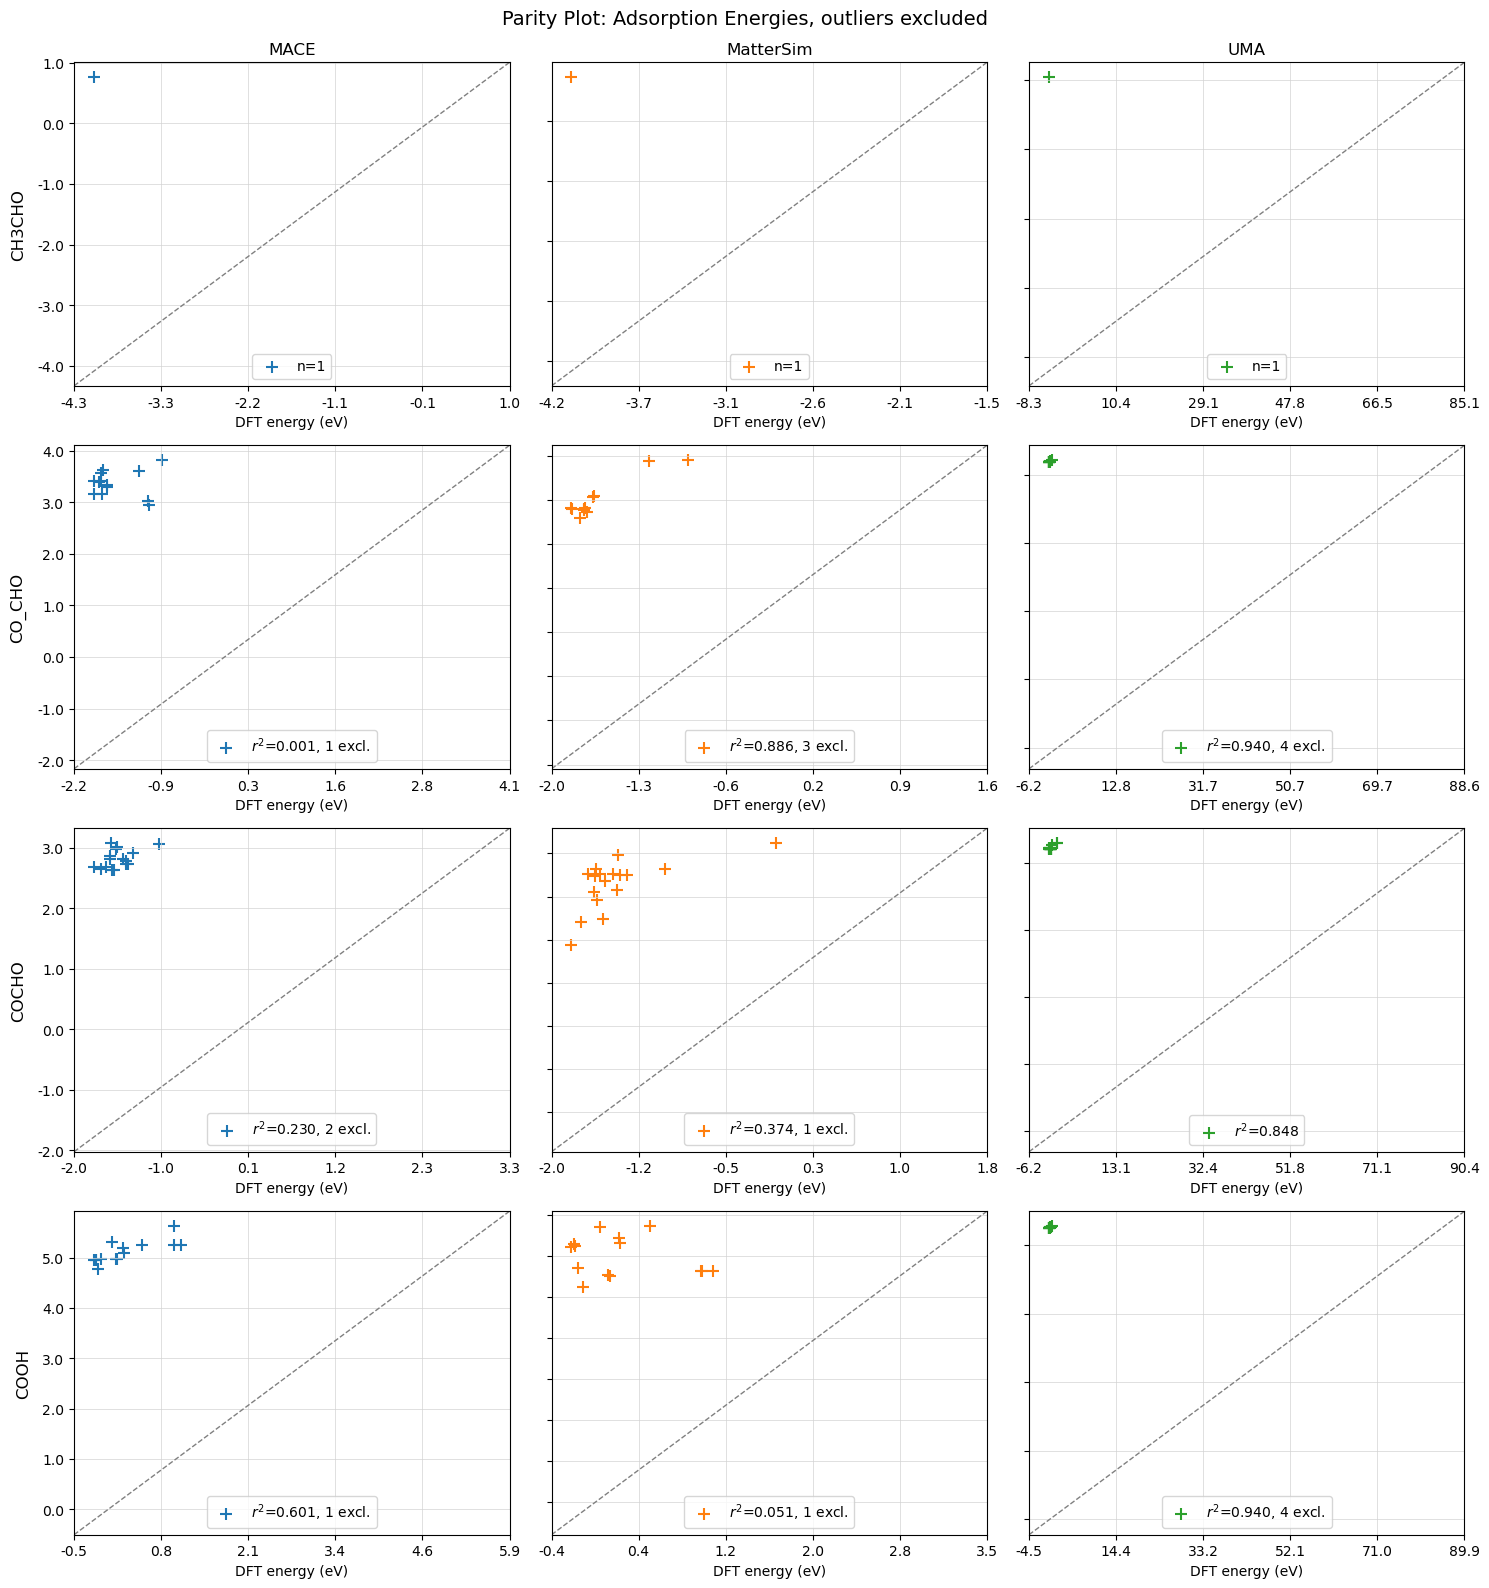

In [93]:
# generate parity plots

# # with no removed points
# parity_plot(df, "total",    "Parity Plot: Total Energies (relaxed MLIPs vs. DFT)")
# parity_plot(df, "adsorbed", "Parity Plot: Adsorption Energies (relaxed MLIPs vs. DFT)")

# with outliers removed
parity_plot(df, "total",    "Parity Plot: Total Energies, outliers excluded", drop_outliers=True, show_outlier_table=True)
parity_plot(df, "adsorbed", "Parity Plot: Adsorption Energies, outliers excluded", drop_outliers=True)

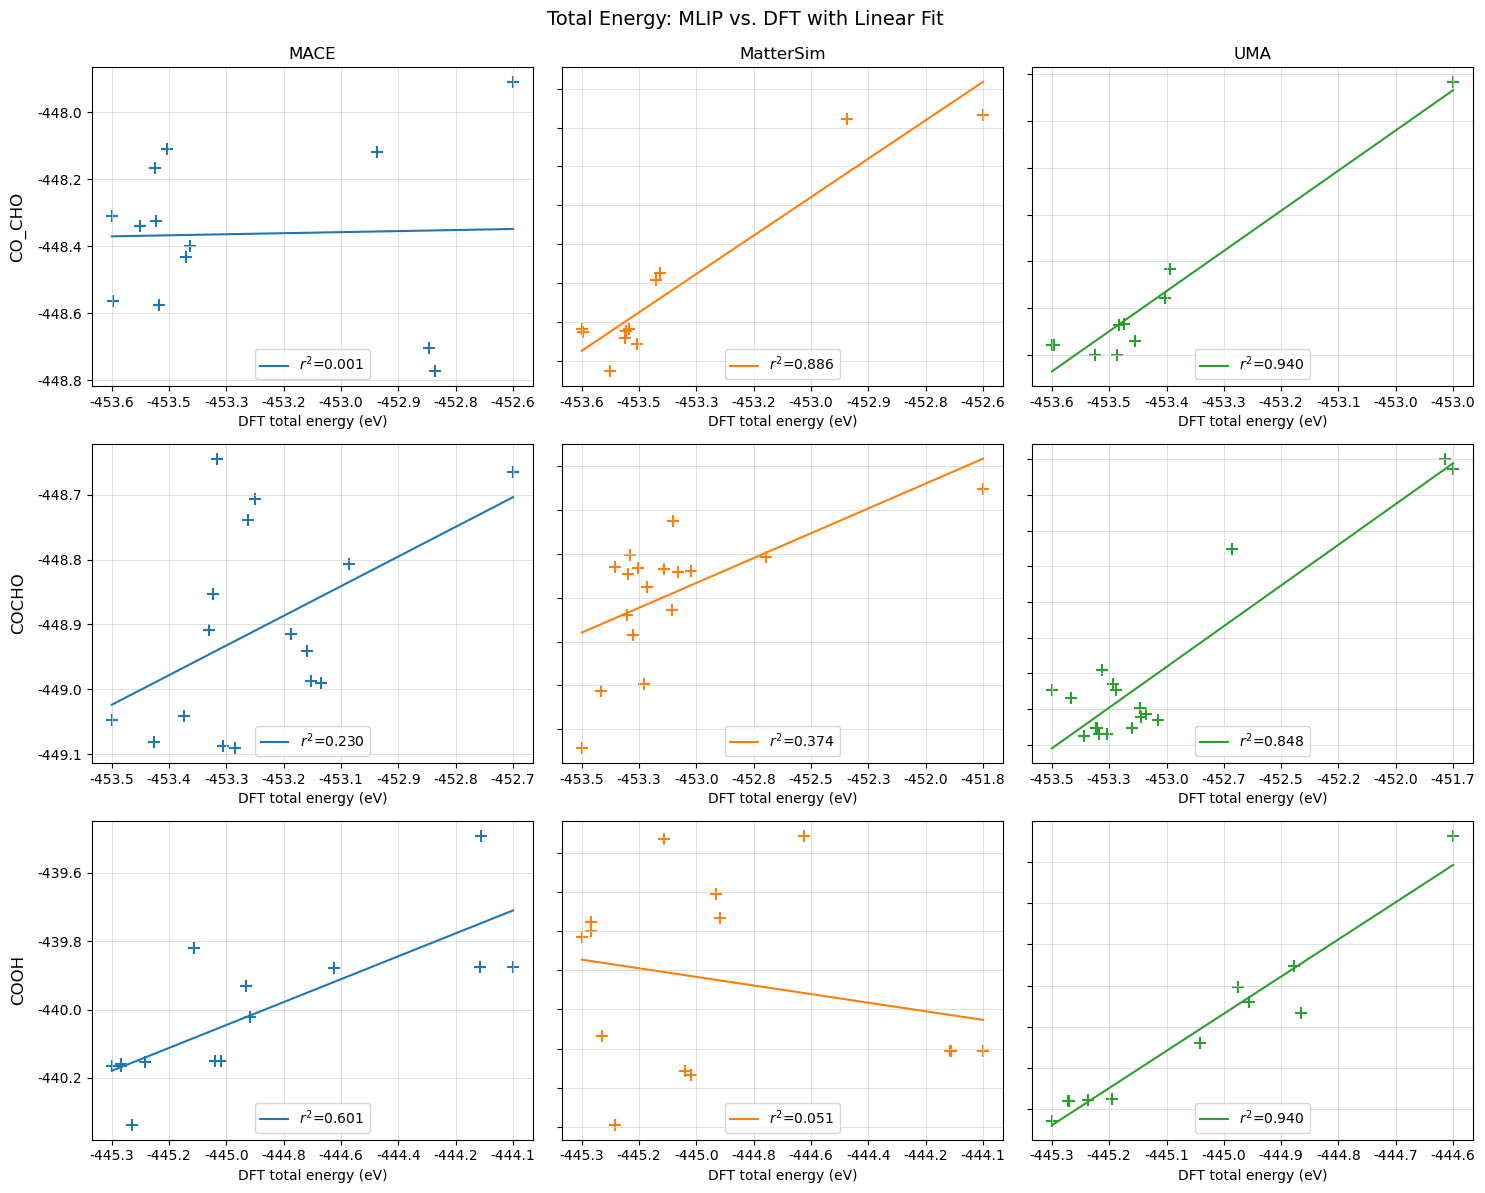

In [ ]:
# plot MLIP energies with linear fit

# linear fit plot (total energies, no parity line)
COLORS = plt.cm.tab10.colors
fmt = FormatStrFormatter('%.1f')
ADSORBATE_CALCS_PLOT = [a for a in ADSORBATE_CALCS if a != "CH3CHO"]
fig, axes = plt.subplots(nrows=len(ADSORBATE_CALCS_PLOT), ncols=len(MODELS),
                        figsize=(5*len(MODELS), 4*len(ADSORBATE_CALCS_PLOT)))
for row, ads in enumerate(ADSORBATE_CALCS_PLOT):
    for col, (model, color) in enumerate(zip(MODELS, COLORS)):
        ax = axes[row][col]
        subset = df[(df['model'] == model['name']) & (df['ads'] == ads)]
        x = subset['dft_total'].to_numpy()
        y = subset['total'].to_numpy()
        keys = subset['run_id'].tolist()
        # drop outliers
        mask, _ = filter_outliers(x, y, keys)
        x = x[mask]
        y = y[mask]
        ax.scatter(x, y, marker='+', s=80, color=color)
        if len(x) >= 2:
            slope, intercept = np.polyfit(x, y, 1)
            r2 = pearsonr(x, y).statistic ** 2
            xs = np.linspace(x.min(), x.max(), 100)
            ax.plot(xs, slope*xs + intercept, color=color, linewidth=1.5,
                    label=f"$r^2$={r2:.3f}")
            ax.legend(loc='lower center')
        else:
            ax.text(0.5, 0.5, "n=1", transform=ax.transAxes, ha='center')
        ax.grid(color='lightgrey', linewidth=0.5)
        ax.set_xlabel("DFT total energy (eV)")
        ax.set_xticks(np.linspace(x.min(), x.max(), 8))
        ax.xaxis.set_major_formatter(fmt)
        ax.yaxis.set_major_formatter(fmt)
        
        if col == 0:
            ax.set_ylabel("MLIP total energy (eV)")
        else:
            ax.tick_params(labelleft=False)
        if row == 0:
            ax.set_title(model['name'], fontsize=12)
        if col == 0:
            ax.set_ylabel(ads, fontsize=12, labelpad=8)
plt.suptitle("Total Energy: MLIP vs. DFT with Linear Fit", y=0.99, fontsize=14)
plt.tight_layout()
plt.show()

In [76]:
# print energetic rank-order agreement

ADS_LIST = list(ADSORBATE_CALCS.keys())
results = []
for model in MODELS:
    subset = df[df['model'] == model['name']]
    total, correct = 0, 0
    top_overlap, bot_overlap = 0, 0
    n_ads = 0
    for ads in ADS_LIST:
        if ads == "CH3CHO":
            continue
        ads_subset = subset[subset['ads'] == ads]
        dft_rank = ads_subset['dft_total'].rank(method='first')
        mlip_rank = ads_subset['total'].rank(method='first')
        agree = dft_rank == mlip_rank
        correct += agree.sum()
        total += len(ads_subset)
        n_ads += 1

        dft_top5 = set(ads_subset.loc[ads_subset['dft_total'].nlargest(5).index, 'run_id'])
        mlip_top5 = set(ads_subset.loc[ads_subset['total'].nlargest(5).index, 'run_id'])
        dft_bot5 = set(ads_subset.loc[ads_subset['dft_total'].nsmallest(5).index, 'run_id'])
        mlip_bot5 = set(ads_subset.loc[ads_subset['total'].nsmallest(5).index, 'run_id'])

        top_overlap += len(dft_top5 & mlip_top5)
        bot_overlap += len(dft_bot5 & mlip_bot5)

    results.append((model['name'], f"{correct}/{total}", f"{top_overlap}/{5*n_ads}", f"{bot_overlap}/{5*n_ads}"))

name_w = max(len(r[0]) for r in results)
agree_w = max(len(r[1]) for r in results)
top_w = max(len(r[2]) for r in results)

print("This gives how many MLIP energies match the DFT energy rank, and how many\n MLIP top and bottom 5 energies match DFT top/bottom 5.")

for name, agree, top, bot in results:
    print(f"{name:<{name_w}}: {agree:>{agree_w}} agree  |  "
            f"top 5: {top:>{top_w}} overlap  |  "
            f"bottom 5: {bot} overlap")

This gives how many MLIP energies match the DFT energy rank, and how many
 MLIP top and bottom 5 energies match DFT top/bottom 5.
MACE     : 6/47 agree  |  top 5: 10/15 overlap  |  bottom 5: 8/15 overlap
MatterSim: 2/47 agree  |  top 5:  6/15 overlap  |  bottom 5: 6/15 overlap
UMA      : 5/47 agree  |  top 5:  8/15 overlap  |  bottom 5: 11/15 overlap


#### Optional tools for examining specific MLIP relaxations and the corresponding DFT runs

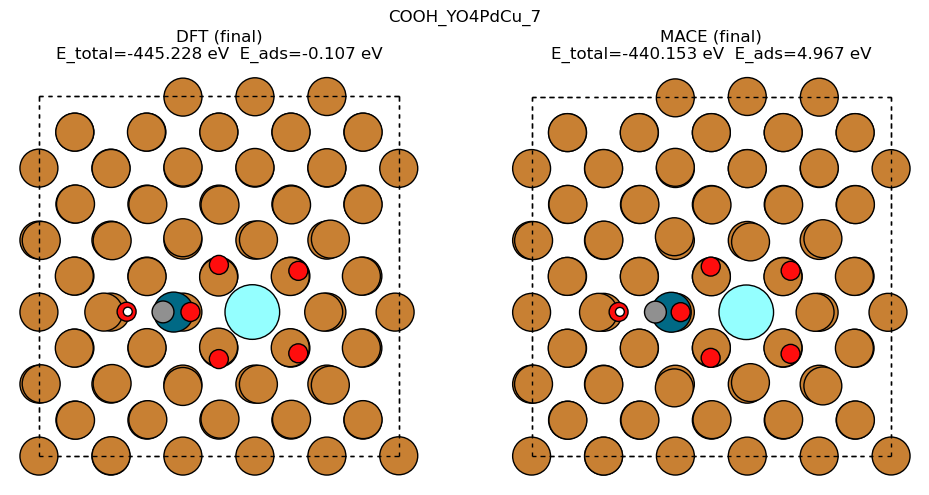

In [77]:
from ase.visualize.plot import plot_atoms

def plot_run_comparison(run_id, model_name, energy_key="adsorbed"):
    # find the run
    run = next(r for r in RUNS if r["run_id"] == run_id)
    
    # load final frames
    dft_frame  = read(f"dft-trajectories/{run_id}_dft.xyz", index=-1)
    mlip_frame = read(f"mlip-trajectories/{model_name}/{run_id}_{model_name.lower()}.traj", index=-1)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    for ax, atoms, label in zip(axes, [dft_frame, mlip_frame], ["DFT (final)", f"{model_name} (final)"]):
        plot_atoms(atoms, ax, radii=0.5, rotation=("0x,0y,0z"))
        e = atoms.get_potential_energy()
        e_ads = ADSORBATE_CALCS[run["ads"]](e)
        ax.set_title(f"{label}\nE_total={e:.3f} eV  E_ads={e_ads:.3f} eV")
        ax.axis("off")
    
    fig.suptitle(run_id)
    plt.tight_layout()
    plt.show()

# usage — paste the run_id from outlier_lookup output:
plot_run_comparison("COOH_YO4PdCu_7", "MACE")

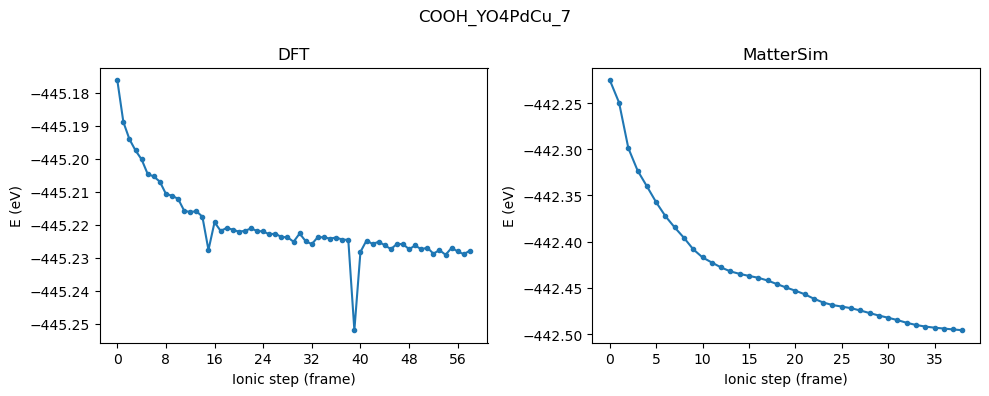

In [78]:
def plot_run_comparison(run_id, model_name):
    dft_frames  = [f for f in iread(f"dft-trajectories/{run_id}_dft.xyz")]
    mlip_frames = [f for f in iread(f"mlip-trajectories/{model_name}/{run_id}_{model_name.lower()}.traj")]
    
    dft_energies_traj  = [f.get_potential_energy() for f in dft_frames]
    mlip_energies_traj = [f.get_potential_energy() for f in mlip_frames]
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    for ax, energies, label in zip(axes, [dft_energies_traj, mlip_energies_traj], ["DFT", model_name]):
        ax.plot(energies, marker='o', markersize=3)
        ax.set_title(label)
        ax.set_xlabel("Ionic step (frame)")
        ax.set_ylabel("E (eV)")
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        # ax.set_xlim(0, len(energies) - 1)        
        # ax.grid(True, linestyle='--', alpha=0.5)
    
    fig.suptitle(run_id)
    plt.tight_layout()
    plt.show()

# use: enter run_id, model_name
plot_run_comparison("COOH_YO4PdCu_7", "MatterSim")

In [79]:
# write .cif to view a relaxation result in VESTA
from pathlib import Path

def render_vesta(run_id, model):
    if model=="DFT":
        filepath = f"dft-trajectories/{run_id}_{model.lower()}.xyz"
    else:
        filepath = f"mlip-trajectories/{model}/{run_id}_{model.lower()}.traj"
    atoms = read(filepath, index=-1)
    if not Path(f"vesta-renders/{run_id}_{model.lower()}.cif").exists():
        write(f"vesta-renders/{run_id}_{model}.cif", atoms)

render_vesta("COOH_YO4PdCu_7", "DFT")
render_vesta("COOH_YO4PdCu_7", "MACE")
render_vesta("COOH_YO4PdCu_7", "MatterSim")
render_vesta("COOH_YO4PdCu_7", "UMA")

